<a href="https://colab.research.google.com/github/gigihArmy/Fungi-Image-Classification/blob/main/Edible_and_poisonous_fungi_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fungi Images Classification (Edible & Non-Edible)

In [1]:
!pip install opendatasets

## Library

In [2]:
import os
import opendatasets as od
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adamax

## Load Datasets

In [3]:
od.download('https://www.kaggle.com/datasets/marcosvolpato/edible-and-poisonous-fungi/data')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: 35048af2611b9f31f8877f733d37dad7
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/marcosvolpato/edible-and-poisonous-fungi


100%|██████████| 257M/257M [00:02<00:00, 127MB/s]

In [4]:
os.listdir('/content/edible-and-poisonous-fungi')

['edible mushroom sporocarp',
 'poisonous sporocarp',
 'poisonous mushroom sporocarp',
 'edible sporocarp']

In [6]:
data_folder_path = '/content/edible-and-poisonous-fungi'
classes = ['edible mushroom sporocarp', 'poisonous mushroom sporocarp']
label_map = {sub: i for i, sub in enumerate(classes)}

#list
images = []
labels = []

#resizing images iteration
for sub in classes:
  sub_path = os.path.join(data_folder_path, sub)
  for filename in os.listdir(sub_path):
    img_path = os.path.join(sub_path, filename)
    #read images
    img = cv2.imread(img_path)
    if img is not None:
      resized = cv2.resize(img, (128, 128))
      images.append(resized)
      labels.append(label_map[sub])

#convert to arrays
images = np.array(images)
labels = np.array(labels)

In [7]:
label_map

{'edible mushroom sporocarp': 0, 'poisonous mushroom sporocarp': 1}

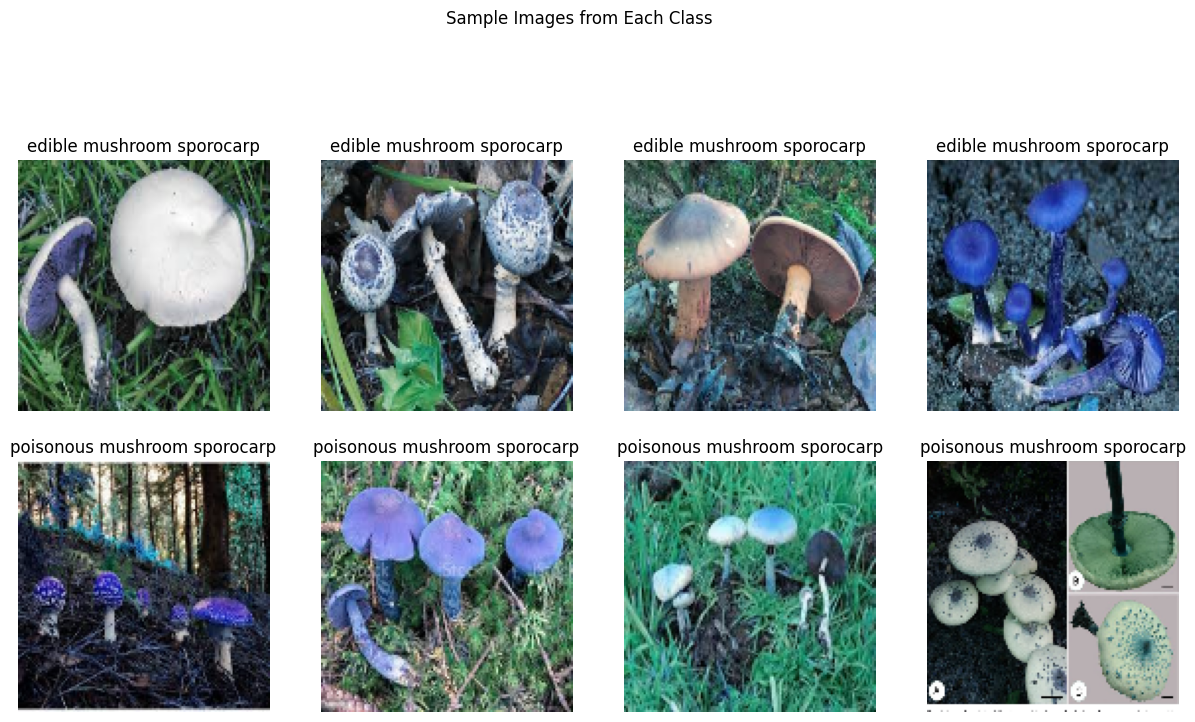

In [9]:
plt.figure(figsize = (15,15))
for i, label in enumerate(classes):
    class_indices = np.where(labels == label_map[label])[0]
    for j in range(4):
        plt.subplot(4, 4, i*4 + j+1)
        plt.imshow(images[class_indices[j]])
        plt.title(label)
        plt.axis('off')
plt.suptitle('Sample Images from Each Class')
plt.show()

## Pre-processing

In [11]:
#split data train & temp
X_train, X_temp, y_train, y_temp = train_test_split(images, labels, test_size=0.4, random_state=42)

#split validation & test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")

Train set: (945, 128, 128, 3)
Validation set: (315, 128, 128, 3)
Test set: (315, 128, 128, 3)


In [12]:
#Normalizing
X_train = X_train / 255.0
X_temp = X_temp / 255.0
X_val = X_val / 255.0
X_test = X_test / 255.0

## Modelling

In [32]:
cnn = Sequential([
    #layer 1
    Conv2D(filters=64, kernel_size=(3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(pool_size=(2,2)),
    #layer 2
    Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    #layer 3
    Conv2D(filters=128, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,325,258 (12.68 MB)

 Trainable params: 3,325,258 (12.68 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
#model compile
cnn.compile(optimizer=Adamax(learning_rate=0.001),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

#callback
callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True)

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_model.keras',
    save_best_only=True,
    monitor='val_loss',
)

In [35]:
history = cnn.fit(X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=20,
        callbacks=[callback, model_checkpoint])

Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.4989 - loss: 0.9095 - val_accuracy: 0.5111 - val_loss: 0.7727
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.6350 - loss: 0.6489 - val_accuracy: 0.6032 - val_loss: 0.6668
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.6792 - loss: 0.5737 - val_accuracy: 0.5841 - val_loss: 0.6859
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.6830 - loss: 0.5963 - val_accuracy: 0.6190 - val_loss: 0.6366
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.7208 - loss: 0.5452 - val_accuracy: 0.6159 - val_loss: 0.6674
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.7485 - loss: 0.5206 - val_accuracy: 0.6571 - val_loss: 0.6458
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.7796 - loss: 0.4557 - val_accuracy: 0.6413 - val_loss: 0.6946
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.7961 - loss: 0.4363 - val_accuracy: 0.6730 - val_loss:

## Model Evaluation

In [36]:
cnn.evaluate(X_test, y_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 388ms/step - accuracy: 0.6461 - loss: 0.6018


[0.6216204762458801, 0.6349206566810608]

In [37]:
y_pred = cnn.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred_classes, target_names=classes))

10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 553ms/step
                              precision    recall  f1-score   support

   edible mushroom sporocarp       0.58      0.83      0.68       147
poisonous mushroom sporocarp       0.76      0.46      0.58       168

                    accuracy                           0.63       315
                   macro avg       0.67      0.65      0.63       315
                weighted avg       0.67      0.63      0.62       315



Text(0.5, 1.0, 'Confusion Matrix')

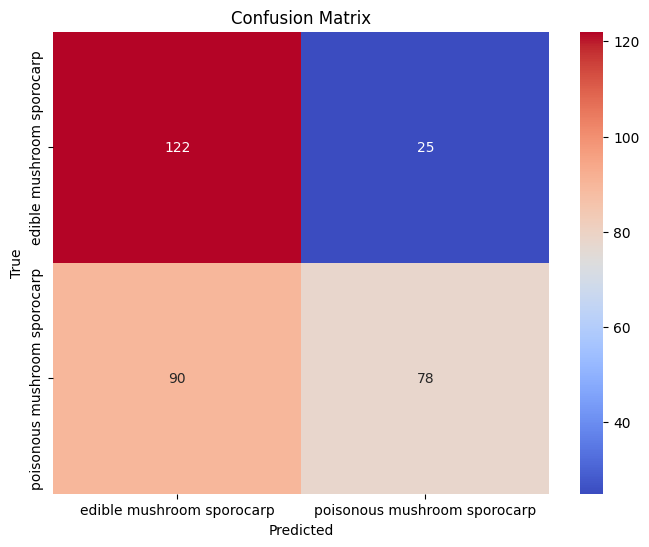

In [38]:
#heatmap visualization
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

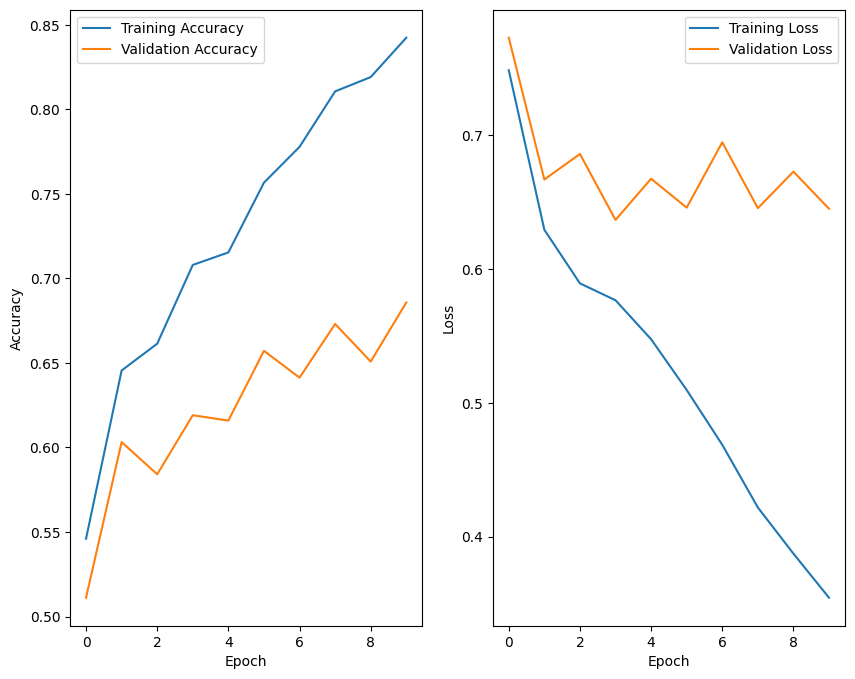

In [39]:
#plot accuracy
plt.figure(figsize=(10, 8))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

#plot loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Inference

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step


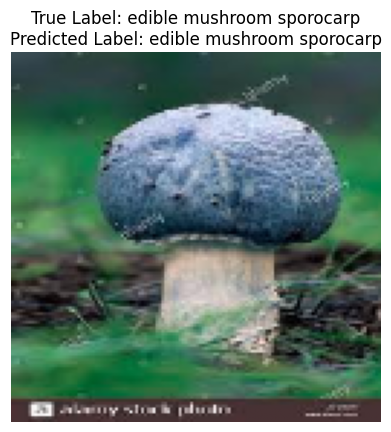

In [41]:
#load model
model = tf.keras.models.load_model('best_model.keras')

sample_image = X_test[0]
sample_label = y_test[0]

sample_image = np.expand_dims(sample_image, axis=0)
prediction = model.predict(sample_image)
predicted_index = np.argmax(prediction, axis=1)[0]
predicted_label = classes[predicted_index]
true_class_label = classes[sample_label]

#display
plt.imshow(sample_image[0])
plt.title(f"True Label: {true_class_label}\nPredicted Label: {predicted_label}")
plt.axis('off')
plt.show()